# Modelo de Classificação de Diabetes para mulheres indianas da etnia Pima 
---

## A) Introdução
---

Esse projeto é o trabalho final proposto no curso [`Scikit-Learn For Machine Learning Classification Problems`]() de Ryan Ahmed, sendo este disponibilizado na plataforma oficial da [Coursera](https://www.coursera.org/).

O dataset utilizado é [Pima Indians Diabetes Dataset](https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset), disponível na plataforma [Kaggle](https://www.kaggle.com/)

O trabalho é de abordagem simples e rápida, para diagnosticar mulheres indianas da etnia Pima, fazendo uso das seguintes bibliotecas linguagem de programação `Python` para análises descritivas e preditivas:

- `Pandas`
- `Matplotlib`
- `Seaborn`
- `Scikit-Learn`
- `XGBoost`

## B) Importação das Bibliotecas
---

In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier

## C) Criação do DataFrame que será utilizado em todo o projeto
---

In [122]:
df = pd.read_csv('diabetes.csv', sep=',')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


## D) Análise Exploratória de Dados
---

### 1. Conferência de valores nulos 
---

Não há valores nulos

In [123]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### 2. Conferência de Duplicatas
---

Não há registros duplicados

In [124]:
df.duplicated().sum()

np.int64(0)

### 3. Conferência de valores únicos 
---

No dataset, os dados registrados são bem diversificados em seus atributos. 

Os único atributo que poderia ser "categorizado", é justamente, o Outcome (resultado), onde há dois valores positivos: `0` (negativo) e `1` (positivo).

As demais colunas possuem vários valores únicos.

In [125]:
df.nunique()

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

### 4. Tradução dos nomes dos atributos
---

In [126]:
df = df.rename(columns={
    'Pregnancies':'num_gravidez',
    'Glucose':'taxa_glicemia',
    'BloodPressure':'pressao_arterial',
    'SkinThickness':'espessura_pele',
    'Insulin':'taxa_insulina',
    'BMI':'imc',
    'DiabetesPedigreeFunction':'funcao_hereditariedade',
    'Age':'idade',
    'Outcome':'diagnostico'
})

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   num_gravidez            768 non-null    int64  
 1   taxa_glicemia           768 non-null    int64  
 2   pressao_arterial        768 non-null    int64  
 3   espessura_pele          768 non-null    int64  
 4   taxa_insulina           768 non-null    int64  
 5   imc                     768 non-null    float64
 6   funcao_hereditariedade  768 non-null    float64
 7   idade                   768 non-null    int64  
 8   diagnostico             768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### 5. Descrição do df
---

Abaixo, está a descrição do df, feita usando o método .describe(), mas cada coluna terá a sua análise em separado e com um histograma.

In [128]:
df.describe()

,num_gravidez,taxa_glicemia,pressao_arterial,espessura_pele,taxa_insulina,imc,funcao_hereditariedade,idade,diagnostico
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [129]:
def print_descricao(nome, nome_col):
    contagem = df[nome_col].count()
    nulas = df[nome_col].isna().sum()
    duplicadas = df[nome_col].duplicated().sum()
    valores_unicos = df[nome_col].nunique()
    media = df[nome_col].mean()
    valor_minimo = df[nome_col].min()
    valor_maximo = df[nome_col].max()
    desvio_padrao = df[nome_col].std()
    quartil_25 = df[nome_col].quantile(0.25)
    quartil_50 = df[nome_col].quantile(0.50)
    quartil_75 = df[nome_col].quantile(0.75)

    print(f'\n\n Análise do atributo {nome}:')
    print(f'\n - No total, há {contagem} células e destas, {nulas} são nulas, {duplicadas} estão duplicadas e o total de valores_unicos são {valores_unicos};')
    print(f'\n - A média aritmética de seus valores é, aproximadamente, {media:.2f};')
    print(f'\n - O valor mínimo registrado é {valor_minimo}, e o máximo, {valor_maximo};')
    print(f'\n - O desvio padrão é, aproximadamente, {desvio_padrao:.2f}. Isto significa que os valores ocilam entre + {desvio_padrao:.2f} e - {desvio_padrao:.2f} em relação a média de {media:.2f};')
    print(f'\n - O valor do quartil de 25% é {quartil_25}. Este ponto mostra onde chega ao certo em 25% dos valores do atributo;')
    print(f'\n - O valor do quartil de 50% é {quartil_50}. Este ponto mostra a mediana dos valores da coluna;')
    print(f'\n - O valor do quartil de 75% é {quartil_75}. Este ponto mostra onde chega ao certo em 25% dos valores do atributo.\n\n')

#### 4.1. Atributo num_gravidez
---

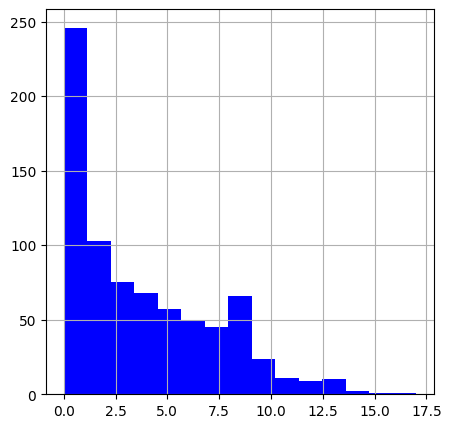

In [130]:
df['num_gravidez'].hist(bins=15, figsize=(5,5), color='b')
plt.show()

In [131]:
print_descricao('Número de gravidez', 'num_gravidez')



 Análise do atributo Número de gravidez:

 - No total, há 768 células e destas, 0 são nulas, 751 estão duplicadas e o total de valores_unicos são 17;

 - A média aritmética de seus valores é, aproximadamente, 3.85;

 - O valor mínimo registrado é 0, e o máximo, 17;

 - O desvio padrão é, aproximadamente, 3.37. Isto significa que os valores ocilam entre + 3.37 e - 3.37 em relação a média de 3.85;

 - O valor do quartil de 25% é 1.0;

 - O valor do quartil de 50% é 3.0;

 - O valor do quartil de 75% é 6.0.




#### 4.2. Atributo taxa_glicemia
---

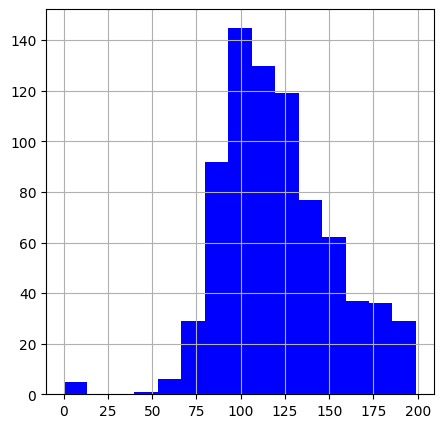

In [132]:
df['taxa_glicemia'].hist(bins=15, figsize=(5,5), color='b')
plt.show()

In [133]:
print_descricao('Taxa de Glicemia', 'taxa_glicemia')



 Análise do atributo Taxa de Glicemia:

 - No total, há 768 células e destas, 0 são nulas, 632 estão duplicadas e o total de valores_unicos são 136;

 - A média aritmética de seus valores é, aproximadamente, 120.89;

 - O valor mínimo registrado é 0, e o máximo, 199;

 - O desvio padrão é, aproximadamente, 31.97. Isto significa que os valores ocilam entre + 31.97 e - 31.97 em relação a média de 120.89;

 - O valor do quartil de 25% é 99.0;

 - O valor do quartil de 50% é 117.0;

 - O valor do quartil de 75% é 140.25.




#### 4.3. Atributo pressao_arterial
---

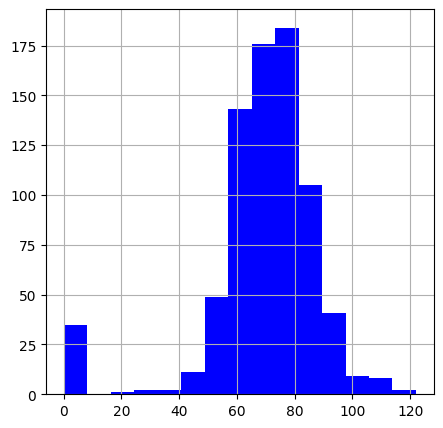

In [134]:
df['pressao_arterial'].hist(bins=15, figsize=(5,5), color='b')
plt.show()

In [135]:
print_descricao('Pressão Arterial', 'pressao_arterial')



 Análise do atributo Pressão Arterial:

 - No total, há 768 células e destas, 0 são nulas, 721 estão duplicadas e o total de valores_unicos são 47;

 - A média aritmética de seus valores é, aproximadamente, 69.11;

 - O valor mínimo registrado é 0, e o máximo, 122;

 - O desvio padrão é, aproximadamente, 19.36. Isto significa que os valores ocilam entre + 19.36 e - 19.36 em relação a média de 69.11;

 - O valor do quartil de 25% é 62.0;

 - O valor do quartil de 50% é 72.0;

 - O valor do quartil de 75% é 80.0.




#### 4.4. Atributo espessura_pele
---

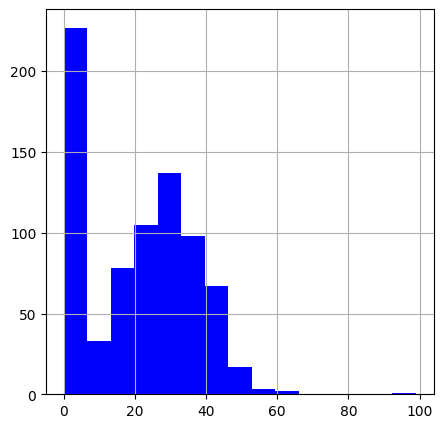

In [136]:
df['espessura_pele'].hist(bins=15, figsize=(5,5), color='b')
plt.show()

In [137]:
print_descricao('Espessura da Pele', 'espessura_pele')



 Análise do atributo Espessura da Pele:

 - No total, há 768 células e destas, 0 são nulas, 717 estão duplicadas e o total de valores_unicos são 51;

 - A média aritmética de seus valores é, aproximadamente, 20.54;

 - O valor mínimo registrado é 0, e o máximo, 99;

 - O desvio padrão é, aproximadamente, 15.95. Isto significa que os valores ocilam entre + 15.95 e - 15.95 em relação a média de 20.54;

 - O valor do quartil de 25% é 0.0;

 - O valor do quartil de 50% é 23.0;

 - O valor do quartil de 75% é 32.0.




#### 4.5. Atributo taxa_insulina
---

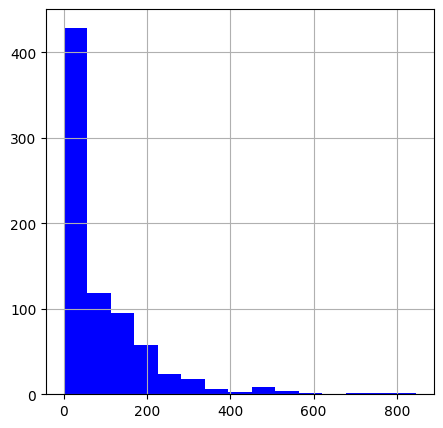

In [138]:
df['taxa_insulina'].hist(bins=15, figsize=(5,5), color='b')
plt.show()

In [139]:
print_descricao('Taxa de Insulina', 'taxa_insulina')



 Análise do atributo Taxa de Insulina:

 - No total, há 768 células e destas, 0 são nulas, 582 estão duplicadas e o total de valores_unicos são 186;

 - A média aritmética de seus valores é, aproximadamente, 79.80;

 - O valor mínimo registrado é 0, e o máximo, 846;

 - O desvio padrão é, aproximadamente, 115.24. Isto significa que os valores ocilam entre + 115.24 e - 115.24 em relação a média de 79.80;

 - O valor do quartil de 25% é 0.0;

 - O valor do quartil de 50% é 30.5;

 - O valor do quartil de 75% é 127.25.




#### 4.6. Atributo imc
---

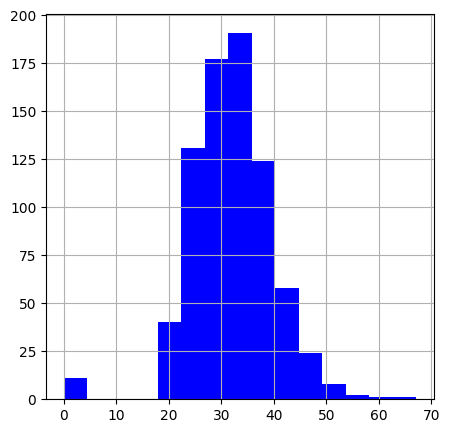

In [140]:
df['imc'].hist(bins=15, figsize=(5,5), color='b')
plt.show()

In [141]:
print_descricao('Índice de Massa Corporal (IMC)', 'imc')



 Análise do atributo Índice de Massa Corporal (IMC):

 - No total, há 768 células e destas, 0 são nulas, 520 estão duplicadas e o total de valores_unicos são 248;

 - A média aritmética de seus valores é, aproximadamente, 31.99;

 - O valor mínimo registrado é 0.0, e o máximo, 67.1;

 - O desvio padrão é, aproximadamente, 7.88. Isto significa que os valores ocilam entre + 7.88 e - 7.88 em relação a média de 31.99;

 - O valor do quartil de 25% é 27.3;

 - O valor do quartil de 50% é 32.0;

 - O valor do quartil de 75% é 36.6.




#### 4.7. Atributo funcao_hereditariedade
---

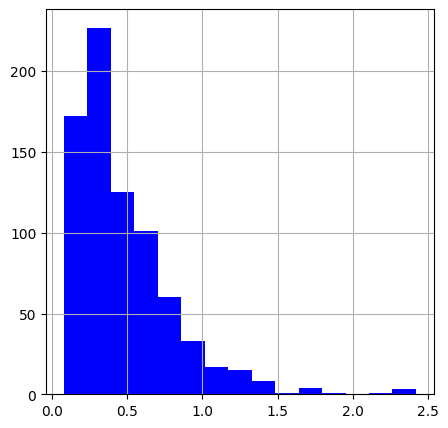

In [142]:
df['funcao_hereditariedade'].hist(bins=15, figsize=(5,5), color='b')
plt.show()

In [143]:
print_descricao('Função de Hereditariedade de Diabetes', 'funcao_hereditariedade')



 Análise do atributo Função de Hereditariedade de Diabetes:

 - No total, há 768 células e destas, 0 são nulas, 251 estão duplicadas e o total de valores_unicos são 517;

 - A média aritmética de seus valores é, aproximadamente, 0.47;

 - O valor mínimo registrado é 0.078, e o máximo, 2.42;

 - O desvio padrão é, aproximadamente, 0.33. Isto significa que os valores ocilam entre + 0.33 e - 0.33 em relação a média de 0.47;

 - O valor do quartil de 25% é 0.24375;

 - O valor do quartil de 50% é 0.3725;

 - O valor do quartil de 75% é 0.62625.




#### 4.8. Atributo idade
---

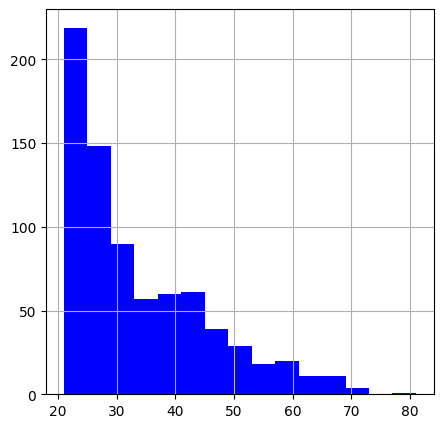

In [144]:
df['idade'].hist(bins=15, figsize=(5,5), color='b')   
plt.show()

In [145]:
print_descricao('Idade', 'idade')



 Análise do atributo Idade:

 - No total, há 768 células e destas, 0 são nulas, 716 estão duplicadas e o total de valores_unicos são 52;

 - A média aritmética de seus valores é, aproximadamente, 33.24;

 - O valor mínimo registrado é 21, e o máximo, 81;

 - O desvio padrão é, aproximadamente, 11.76. Isto significa que os valores ocilam entre + 11.76 e - 11.76 em relação a média de 33.24;

 - O valor do quartil de 25% é 24.0;

 - O valor do quartil de 50% é 29.0;

 - O valor do quartil de 75% é 41.0.




#### 4.9. Atribtuto diagnostico
---

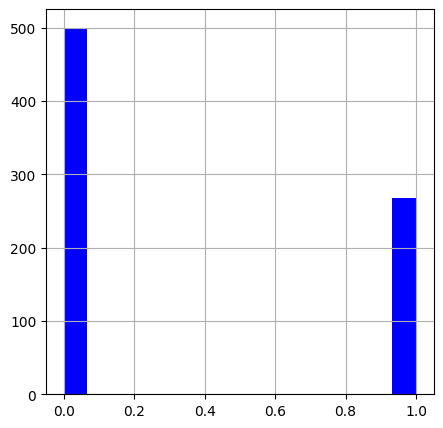

In [146]:
df['diagnostico'].hist(bins=15, figsize=(5,5), color='b')   
plt.show()

In [147]:
print_descricao('Diagnóstico de Diabetes', 'diagnostico')



 Análise do atributo Diagnóstico de Diabetes:

 - No total, há 768 células e destas, 0 são nulas, 766 estão duplicadas e o total de valores_unicos são 2;

 - A média aritmética de seus valores é, aproximadamente, 0.35;

 - O valor mínimo registrado é 0, e o máximo, 1;

 - O desvio padrão é, aproximadamente, 0.48. Isto significa que os valores ocilam entre + 0.48 e - 0.48 em relação a média de 0.35;

 - O valor do quartil de 25% é 0.0;

 - O valor do quartil de 50% é 0.0;

 - O valor do quartil de 75% é 1.0.




### 6. Matriz de Correlação de Pearson
---

Será apresentada a Matriz de Correlação de Pearson entre todos os atributos.

A análise mais importante é a correlação entre as futuras features e o futuro target, o atributo `diagnostico`, para que se possa ter um maior entendimento de como funcionará o modelo.

<Axes: >

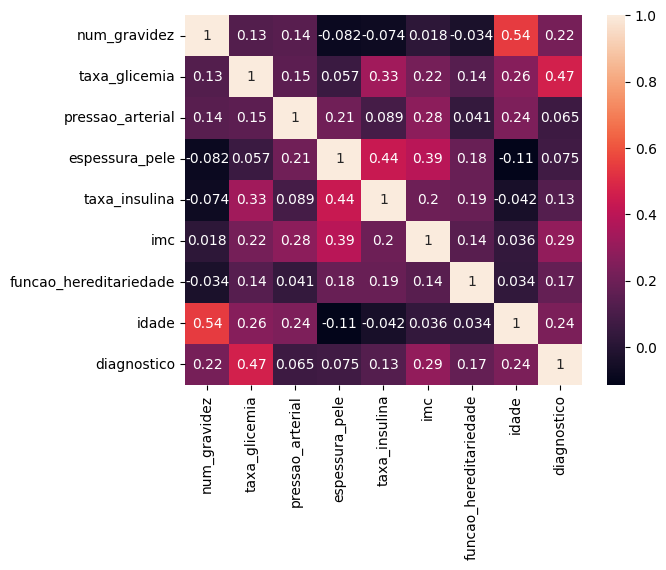

In [148]:
sns.heatmap(df.corr(), annot=True)

| Feature | Correlação com o Diagnóstico |
| :---: | :---: |
| `num_gravidez` | 0.22 |
| `taxa_glicemia`| **0.47** |
| `pressao_arterial` | **0.065** |
| `espessura_pele` | **0.075** |
| `taxa_insulina` | 0.13 |
| `imc` | 0.29 |
| `funcao_hereditariedade` | 0.17 |
| `idade` | 0.24 |

As futuras features que tem as menores correlações, mesmo que positivas, com o target `diagnostico` são `pressao_arterial` (0.065) e `espessura_pele` (0.075). 

A feature que tem maior correlação é `taxa_glicemia` (0.47), seguida `imc`(0.29), `idade` (0.24).

Por último, `funcao_hereditariedade` (0.17) e `taxa_insulina` (0.17), tem uma correlação muito acima das menores, mas visivelmente abaixo das maiores.

É visível que algumas features são muito mais relevantes para o diagnóstico do que outras.

## E) Treino e Teste do Modelo de Classificação
---

### 7. Divisão entre Target e Features
---

In [149]:
# Features: seleciona o df e exclui apenas o Target (diagnostico)
X = df.drop(columns='diagnostico')

In [150]:
# Target: seleciona apenas o atributo diagnostico
y = df['diagnostico']

In [151]:
X.shape

(768, 8)

In [152]:
y.shape

(768,)

### 8. Divisão dos dados para treino e teste
---

In [153]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42) # test_size = 0.2 prevê que serão usados 80% dos dados para teste e 20% para treino 

**Explicando os parâmetros da função train_test_split:**
- x é a variável que contém as features.
- y é a variável que contém o target.
- test_size, com o valor 0,2 prevê que 80% dos dados do dataset serão usados para treino e 20%, para testes.
- random_state=42 garante que a divisão dos dados seja sempre a mesma em cada execução, permitindo a reprodutibilidade dos resultados.

In [154]:
X_treino.shape

(614, 8)

In [155]:
X_teste.shape

(154, 8)

In [156]:
y_treino.shape

(614,)

In [157]:
y_teste.shape

(154,)

### 9. Treino do XGBClassifier com o Scikit-Learn
---

In [173]:
model = XGBClassifier(objective='binary:logistic', eval_metric='error', learning_rate='0.5', max_depth=3, n_estimators=100)
model.fit(X_treino, y_treino)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='error', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate='0.5', max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

**Explicando os parâmetros utilizados em XGBClassifier:**

- `objective='binary:logistic'` - Define que o problema é de classificação binária, ou seja, prever duas classes (True/False, 0/1)
  
- `eval_metric='error'` - Métrica de avaliação usada durante o treino. Aqui, “error” significa a taxa de erro de classificação (proporção de previsões incorretas)

- `learning_rate=0.3` - Também chamado de eta. Controla o tamanho do passo em cada atualização. Valores menores tornam o aprendizado mais lento, mas podem melhorar a generalização

- `max_depth=1` - Profundidade máxima das árvores de decisão. Árvores rasas (como 1) reduzem complexidade e ajudam a evitar overfitting (decorar os dados), mas podem limitar a capacidade de capturar relações complexas. Havia atribuído 1, mas aumentei pois uma árvore seria simples para pegar sinais mais sutis

- `n_estimators=100` - Número de árvores (ou rodadas de boosting) que serão treinadas. Mais árvores aumentam a capacidade do modelo, mas também o risco de overfitting se não houver regularização. Havia atribuído 10, mas aumentei o número de árvores para aumentar precisão

- `scale_pos_weight=2` - Equilibra os pesos positivos e negativos. Adicionei posteriormente, pois o modelo estava com dificuldade de atribuir o positivo a diabetes 


### 10. Determinando a acurácia total do modelo
---

In [174]:
acuracia_total = model.score(X_teste, y_teste)

print(f'O percentual total de acurácia do modelo, aproximado é de {(acuracia_total*100):.2f}')

O percentual total de acurácia do modelo, aproximado é de 70.78


### 11. Predição com os dados de features separados para teste
---

In [175]:
y_predicao = model.predict(X_teste)
y_predicao

array([0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0])

### 12. Relatório de Classificação
---

In [176]:
relatorio_classificacao = classification_report(y_teste, y_predicao)
print(relatorio_classificacao)

              precision    recall  f1-score   support

           0       0.79      0.74      0.76        99
           1       0.58      0.65      0.62        55

    accuracy                           0.71       154
   macro avg       0.69      0.70      0.69       154
weighted avg       0.72      0.71      0.71       154



**Explicação sobre possíveis resultados:**

- TP (True Positive): modelo previu "positivo" e realmente era positivo.
    Exemplo: modelo disse que o paciente tem a doença, e essa é a realidade.

- FP (False Positive): modelo previu "positivo", mas na realidade era negativo.
    Exemplo: modelo disse que o paciente tem a doença, mas ele não a tem (`falso alarme`).

- FN (False Negative): modelo previu "negativo", mas na realidade era positivo.
    Exemplo: modelo disse que o paciente não tem a doença, mas ele a tem (`erro crítico`).

- TN (True Negative): modelo previu "negativo" e realmente era negativo.
    Exemplo: modelo disse que o paciente não tem a doença, e essa é a realidade.

**Explicação do Relatório de Classificação:**

- Precision:  confiabilidade do modelo para cada classe. Dessa forma, o modelo acerta 90% das vezes em que inferir que é negativo e 58% das vezes que inferir ser positivo. É a razão TP/(TP+FP)
- Recall: conhecido como Taxa de Detecção. Faz com que o modelo consiga identificar mais instâncias de classes de interesse. No contexto, faz com que o modelo consiga enxergar mais mulheres sem deixá-las sem um diagnóstico. É a razão TP/(TP+FN)
- F1-Score: média harmônica entre Precisão e Recall. Promove o equilíbrio entre ambas métricas. Atinge seu melhor valor em 1 e o pior valor em 0.
- Support: suporte. Indica a quantidade real de cada classe. No caso, foram 106 para negativo e 48 para positivo.
- Accuracy: acurácia. Representa o percentual total de acertos.
- Macro AVG: média aritmética entre as classes.
- Weighted AVG: média ponderada entre as classes.

**Análise:**

Para o modelo, todas as características descritas no Relatório de Classificação são muito importantes. Contudo, o Recall é uma característica que se destaca para o contexto de atendimento ao paciente e diagnóstico, já que trabalhá-lo e aprimorá-lo, garantem que o modelo consiga abranger mais e diagnosticar mais mulheres em relação ao diabetes. Por isso, é importante mantê-la mais aprimorada e equilibrada possível. 

### 13. Matriz de Confusão e Desempenho do Modelo
---

<Axes: >

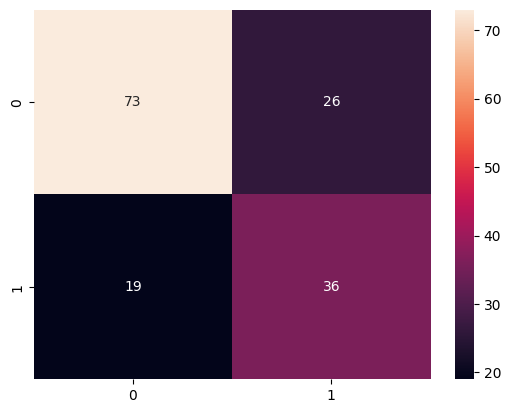

In [177]:
matriz_confusao = confusion_matrix(y_teste, y_predicao)
sns.heatmap(matriz_confusao, annot=True)

In [163]:
(tn, fp), (fn, tp) = matriz_confusao
total = (tn+fp+fn+tp)

In [164]:
def percentual(var, total):
    percentual = (var/total)*100
    return percentual

In [168]:
print('A Matriz de Confusão do Modelo de Classificação para Diagnóstico de Diabetes de mulheres indianas da etnia Pima mostra que o desempenho do modelo foi:')
print(f'\n O total de predições de teste foi {total}')
print(f'\n - Verdadeiros Negativos (TN): {tn}, o que equivale a {percentual(tn, total):.2f}%.')
print(f'\n - Falsos Negativos (FN): {fn}, o que equivale a {percentual(fn, total):.2f}%.')
print(f'\n - Verdadeiros Positivos (TP): {tp}, o que equivale a {percentual(tp, total):.2f}%.')
print(f'\n - Falsos Positivos (FP): {fp}, o que equivale a {percentual(fp, total):.2f}%.')
print(f'\n\n - Percentual de Acertos: {tn + tp}, o que equivale a {percentual(tn+tp, total):.2f}%.')
print(f'\n - Percentual de Erros: {fn + fp}, o que equivale a {percentual(fn+fp, total):.2f}%.')

A Matriz de Confusão do Modelo de Classificação para Diagnóstico de Diabetes de mulheres indianas da etnia Pima mostra que o desempenho do modelo foi:

 O total de predições de teste foi 154

 - Verdadeiros Negativos (TN): 73, o que equivale a 47.40%.

 - Falsos Negativos (FN): 19, o que equivale a 12.34%.

 - Verdadeiros Positivos (TP): 36, o que equivale a 23.38%.

 - Falsos Positivos (FP): 26, o que equivale a 16.88%.


 - Percentual de Acertos: 109, o que equivale a 70.78%.

 - Percentual de Erros: 45, o que equivale a 29.22%.
